In [30]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing import TypedDict,Annotated
from langchain.chat_models import init_chat_model
from langchain_core.messages import BaseMessage,SystemMessage,HumanMessage

In [31]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [32]:
from dotenv import load_dotenv
load_dotenv()

True

In [33]:
model=init_chat_model(
    "openai/gpt-oss-120b",
    model_provider="groq",
    temperature=0.4
)

In [34]:
def chat_message(state:ChatState):
    response=model.invoke(state["messages"])
    return {"messages":[response]}

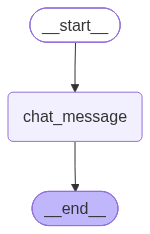

In [35]:
graph=StateGraph(ChatState)

graph.add_node("chat_message",chat_message)

graph.add_edge(START,"chat_message")
graph.add_edge("chat_message",END)

workflow=graph.compile()
workflow

In [38]:
initial_state={
    "messages":[HumanMessage(content="what is object oriented programming")]
}
final_state=workflow.invoke(initial_state)

In [39]:
final_state

{'messages': [HumanMessage(content='what is object oriented programming', additional_kwargs={}, response_metadata={}, id='fb97a801-4142-48bc-859f-0c707641ba3b'),
  AIMessage(content='**Object‑Oriented Programming (OOP)** is a programming paradigm that organizes software around *objects*—self‑contained units that combine data (attributes or fields) and behavior (methods or functions). Instead of writing a linear sequence of instructions, you model the problem domain as a collection of interacting objects that mirror real‑world entities or abstract concepts.\n\n---\n\n## Core Concepts\n\n| Concept | What it means | Typical syntax (e.g., Python) |\n|---------|---------------|-------------------------------|\n| **Class** | A blueprint for creating objects. It defines the attributes and methods that its instances will have. | `class Car:` |\n| **Object / Instance** | A concrete realization of a class. Each object has its own state (attribute values). | `my_car = Car()` |\n| **Encapsulation*

In [40]:
final_state["messages"][-1].content

'**Object‑Oriented Programming (OOP)** is a programming paradigm that organizes software around *objects*—self‑contained units that combine data (attributes or fields) and behavior (methods or functions). Instead of writing a linear sequence of instructions, you model the problem domain as a collection of interacting objects that mirror real‑world entities or abstract concepts.\n\n---\n\n## Core Concepts\n\n| Concept | What it means | Typical syntax (e.g., Python) |\n|---------|---------------|-------------------------------|\n| **Class** | A blueprint for creating objects. It defines the attributes and methods that its instances will have. | `class Car:` |\n| **Object / Instance** | A concrete realization of a class. Each object has its own state (attribute values). | `my_car = Car()` |\n| **Encapsulation** | Bundling data and the methods that operate on that data, and restricting direct access to some of the object\'s internals. | Private attributes: `self.__speed` |\n| **Inheritance

In [42]:
while True:
    query=input("Type here:")
    if query.strip().lower() in ['exit','quit','bye']:
        print("User stopped querying")
        break
    else:
        initial_state={"messages":[query]}
        final_state=workflow.invoke(initial_state)
        print(f"\n{final_state["messages"][-1].content}\n")
        print("*" * 50)



The device we call the **telephone** was not “discovered” so much as **invented**.  

**Alexander Graham Bell** is most widely credited with inventing the first practical telephone. On March 10 1876 he filed a patent for a device that could transmit clear speech electrically, and on March 10 1876 (the same day as a competing filing by Elisha Gray) his U.S. Patent No. 174,465 was granted. Bell’s first successful demonstration of voice transmission over a wire took place on March 10‑12, 1876, when he famously said, “Mr. Watson, come here, I want to see you,” to his assistant Thomas Watson.

### Other contributors worth noting
- **Antonio Meucci** (Italy, 1849) built an early voice‑communication device he called the “telettrofono.” In 2002 the U.S. Congress passed a resolution recognizing his work as a forerunner of the telephone.
- **Elisha Gray** (U.S.) filed a caveat (a provisional patent) for a similar device on the same day Bell filed his patent. A legal battle ensued, and Bell’s pa